In [1]:
import yaml
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from src.features.plot import plot_umap

/Users/user/code/research/proton-kaon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

inference_dir = Path(cfg["output"]["inference_dir"]) / name

train = np.load(inference_dir / "train.npz")
val   = np.load(inference_dir / "val.npz")
kaon  = np.load(inference_dir / "kaon.npz")

train_latents = train["latents"]
train_recon   = train["recon"]
train_re      = train["re"]

val_latents   = val["latents"]
val_recon     = val["recon"]
val_re        = val["re"]

kaon_latents  = kaon["latents"]
kaon_recon    = kaon["recon"]
kaon_re       = kaon["re"]

In [3]:
features = pd.read_pickle('/Volumes/easystore/proton-kaon/features/features.pkl')

In [4]:
index = np.load('/Volumes/easystore/proton-kaon/training/split_p.npz')

In [5]:
train_features = features[features['particle_type'] == 'proton'].iloc[index['train_idx']]
val_features = features[features['particle_type'] == 'proton'].iloc[index['val_idx']]
kaon_features = features[features['particle_type'] == 'kaon']

In [6]:
(train_latents.shape, train_features.shape), (val_latents.shape, val_features.shape), (kaon_latents.shape, kaon_features.shape)

(((9419, 4), (9419, 33)), ((1047, 4), (1047, 33)), ((8227, 4), (8227, 33)))

In [7]:
all_latents = np.vstack([train_latents, val_latents, kaon_latents])
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
reducer.fit(all_latents)

train_umap = reducer.transform(train_latents)
val_umap = reducer.transform(val_latents)
kaon_umap = reducer.transform(kaon_latents)

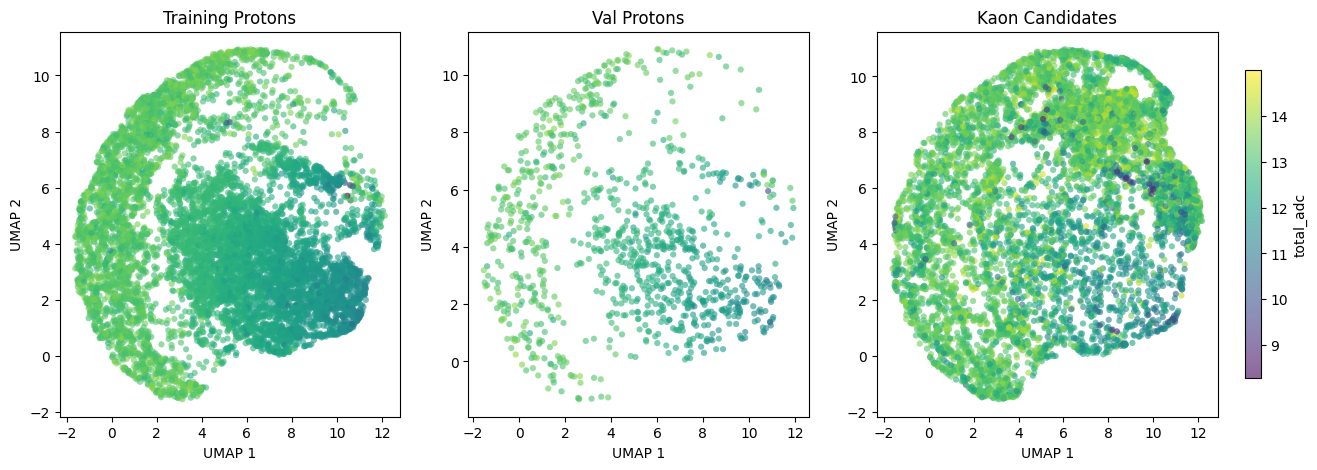

In [8]:
fig, axes = plot_umap(train_umap, train_features, val_umap, val_features, kaon_umap, kaon_features, 'total_adc')
plt.show()

In [11]:
import os
from pathlib import Path

# Get all feature names (exclude metadata columns)
metadata_cols = {'run', 'subrun', 'event', 'particle_type', 'height', 'chi_squared_kaon', 'chi_squared_proton', 'log_likelihood_kaon', 'log_likelihood_proton'}
feature_names = [col for col in train_features.columns if col not in metadata_cols]

# Create output directory
plot_dir = Path('../figs/umap')
plot_dir.mkdir(parents=True, exist_ok=True)

# Plot each feature
for feature in feature_names:
    try:
        fig, axes = plot_umap(train_umap, train_features, val_umap, val_features, kaon_umap, kaon_features, feature)
        
        # Save figure
        out_path = plot_dir / f'{feature}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f'✓ {feature}')
    except Exception as e:
        print(f'✗ {feature}: {e}')
        plt.close()

print(f'\nSaved {len(feature_names)} plots to {plot_dir.resolve()}/')

✓ total_adc
✓ mean_adc
✓ median_adc
✓ max_adc
✓ std_adc
✓ adc_entropy
✓ n_pixels
✓ solidity
✓ bragg_peak_height
✓ bragg_peak_position
✓ bragg_peak_ratio
✓ bragg_peak_to_median
✓ end_vs_start_ratio
✓ last_quartile_mean
✓ first_quartile_mean
✓ bragg_rise_slope
✓ peak_integral_fraction
✓ bragg_peak_width
✓ profile_cv
✓ monotonic_rise_fraction
✓ relative_peak_energy
✓ profile_skewness
✓ profile_kurtosis
✓ n_local_maxima

Saved 24 plots to /Users/user/code/research/proton-kaon/figs/umap/
